<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../../utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Structural Breaks &amp; Explosive Bubbles
    </h1>
  </div>
</div>

Explosive bubbles leave a statistical fingerprint: a temporary **mildly
explosive root** in the price level. De Prado's single-window **SADF**
(Phillips-Wu-Yu 2011, AFML ch.17) dates a bubble with an ADF window anchored at
the sample origin. The trouble: that anchor forces every later window to carry the
whole calm pre-sample, so a second, weaker bubble is diluted and masked. The
**GSADF / BSADF** test (Phillips-Shi-Yu 2015) instead sups the ADF statistic over
*both* window endpoints, testing each episode on its own sub-sample, so it recovers
and date-stamps multiple bubbles where SADF collapses them to about one.

We build a series with two explosive episodes (a strong early one and a weaker
later one) and show SADF finds only the first while GSADF/BSADF recovers both.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# --- Local source bootstrap -------------------------------------------------
# The admitted Stage-1 methods demonstrated here are merged in the RiskLabAI.py
# source tree but not yet in a tagged PyPI release, so we put the local source
# ahead of any installed copy. Once these ship in a release this block is a
# no-op and a plain `pip install RiskLabAI` is enough.
import sys
from pathlib import Path
_cands = [p / "RiskLabAI.py" for p in [Path.cwd(), *Path.cwd().parents]]
_cands.append(Path(r"C:/risklab/risklabai/RiskLabAI.py"))
for _src in _cands:
    if (_src / "RiskLabAI" / "__init__.py").exists():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({  # theme-adaptive figures: transparent bg + neutral-gray foreground
    "figure.facecolor": "none", "axes.facecolor": "none",
    "savefig.facecolor": "none", "savefig.transparent": True,
    "text.color": "#888888", "axes.labelcolor": "#888888", "axes.titlecolor": "#888888",
    "axes.edgecolor": "#888888", "xtick.color": "#888888", "ytick.color": "#888888",
    "grid.color": "#888888", "grid.alpha": 0.3, "legend.framealpha": 0.0,
})


In [2]:
from RiskLabAI.features.structural_breaks import (
    get_sadf_sequence,            # single-window SADF date-stamp (origin-anchored)
    get_bsadf_sequence,           # backward sup-ADF date-stamp (Phillips-Shi-Yu)
    get_gsadf_statistic,          # GSADF = max of the BSADF sequence
    psy_minimum_window,           # PSY rule for the minimum window length
    simulate_psy_critical_values, # finite-sample critical values by simulation
    get_bubble_episodes,          # date-stamp episodes from a statistic vs its CV
)

## 1. A price series with two explosive bubbles

We simulate a daily log-price that is a random walk except for two explosive
windows: a **strong** early bubble (AR coefficient 1.06) and a **weaker, later**
one (1.025), each followed by a short collapse. The second episode is the one a
single origin-anchored window struggles to see.

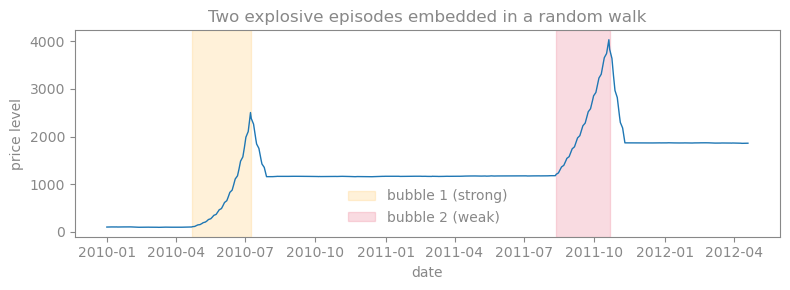

In [3]:
def simulate_two_bubbles(seed=11, n=600, base=100.0, noise=1.0,
                         c1=1.06, c2=1.025, bub1=(80, 135), bub2=(420, 470)):
    rng = np.random.default_rng(seed)
    p = np.zeros(n); p[0] = base
    for t in range(1, n):
        e = rng.standard_normal() * noise
        if bub1[0] <= t < bub1[1]:            # strong early bubble
            p[t] = c1 * p[t - 1] + e
        elif bub2[0] <= t < bub2[1]:          # weaker later bubble
            p[t] = c2 * p[t - 1] + e
        elif bub1[1] <= t < bub1[1] + 15 or bub2[1] <= t < bub2[1] + 15:
            p[t] = 0.95 * p[t - 1] + e        # collapse
        else:
            p[t] = p[t - 1] + e               # random walk
        p[t] = max(p[t], 1.0)
    idx = pd.date_range("2010-01-01", periods=n, freq="B")
    return pd.Series(p, index=idx)

price = simulate_two_bubbles()
log_price = np.log(price)

plt.figure(figsize=(8, 3))
plt.plot(price.index, price.values, lw=1)
plt.axvspan(price.index[80], price.index[135], color="orange", alpha=0.15, label="bubble 1 (strong)")
plt.axvspan(price.index[420], price.index[470], color="crimson", alpha=0.15, label="bubble 2 (weak)")
plt.xlabel("date"); plt.ylabel("price level"); plt.legend()
plt.title("Two explosive episodes embedded in a random walk")
plt.tight_layout(); plt.show()

## 2. Single-window SADF dilutes the later bubble

`get_sadf_sequence` is the date-stamping sequence for de Prado's SADF: at each
endpoint it runs an ADF test on an expanding window **anchored at the sample
origin**. Because every late window still contains the long calm pre-sample, the
weaker second bubble is averaged away.

In [4]:
nmin = psy_minimum_window(len(log_price))
print(f"minimum window length (PSY rule): {nmin} observations")

sadf = get_sadf_sequence(log_price, nmin)
print(f"SADF sequence: {sadf.size} points, max t-stat = {sadf.max():.2f}")

minimum window length (PSY rule): 50 observations
SADF sequence: 550 points, max t-stat = 14.05


## 3. GSADF / BSADF test each episode on its own sub-sample

`get_bsadf_sequence` sups the ADF statistic over all window start points, so a
later episode is tested on a window that starts *near* it rather than at the origin.
`get_gsadf_statistic` is the maximum of that sequence (the global test statistic).
We compare both date-stamping sequences against simulated finite-sample critical
values from `simulate_psy_critical_values` and read off episodes with
`get_bubble_episodes`.

In [5]:
bsadf = get_bsadf_sequence(log_price, nmin)
gsadf = get_gsadf_statistic(log_price, nmin)

cv = simulate_psy_critical_values(len(log_price), nmin, n_simulations=500, level=0.95)
print(f"GSADF statistic = {gsadf:.2f}   |   95% critical value = {cv['gsadf_global_cv']:.2f}"
      f"   ->  {'explosive behaviour detected' if gsadf > cv['gsadf_global_cv'] else 'no detection'}")

sadf_cv  = pd.Series(cv["sadf_sequence_cv"],  index=sadf.index)
bsadf_cv = pd.Series(cv["bsadf_sequence_cv"], index=bsadf.index)

sadf_episodes  = get_bubble_episodes(sadf,  sadf_cv,  min_duration=5)
bsadf_episodes = get_bubble_episodes(bsadf, bsadf_cv, min_duration=5)

print(f"\nSADF  (origin-anchored) date-stamps {len(sadf_episodes)} episode(s):")
for a, b in sadf_episodes:
    print(f"   {a.date()}  ->  {b.date()}")
print(f"BSADF (Phillips-Shi-Yu) date-stamps {len(bsadf_episodes)} episode(s):")
for a, b in bsadf_episodes:
    print(f"   {a.date()}  ->  {b.date()}")

GSADF statistic = 28.14   |   95% critical value = 2.22   ->  explosive behaviour detected

SADF  (origin-anchored) date-stamps 1 episode(s):
   2010-04-26  ->  2010-09-21
BSADF (Phillips-Shi-Yu) date-stamps 2 episode(s):
   2010-04-23  ->  2010-08-30
   2011-08-12  ->  2011-11-09


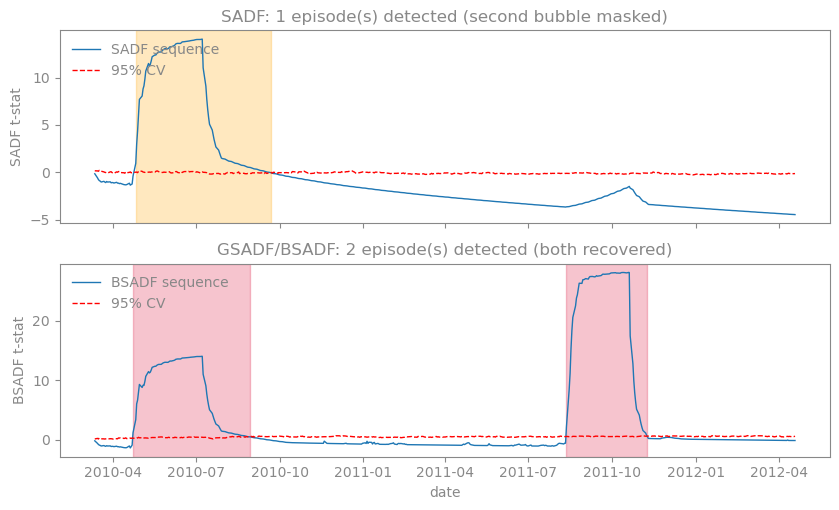

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.5, 5.2), sharex=True)

ax1.plot(sadf.index, sadf.values, lw=1, label="SADF sequence")
ax1.plot(sadf_cv.index, sadf_cv.values, lw=1, ls="--", c="red", label="95% CV")
for a, b in sadf_episodes:
    ax1.axvspan(a, b, color="orange", alpha=0.25)
ax1.set_ylabel("SADF t-stat"); ax1.legend(loc="upper left")
ax1.set_title(f"SADF: {len(sadf_episodes)} episode(s) detected (second bubble masked)")

ax2.plot(bsadf.index, bsadf.values, lw=1, label="BSADF sequence")
ax2.plot(bsadf_cv.index, bsadf_cv.values, lw=1, ls="--", c="red", label="95% CV")
for a, b in bsadf_episodes:
    ax2.axvspan(a, b, color="crimson", alpha=0.25)
ax2.set_ylabel("BSADF t-stat"); ax2.set_xlabel("date"); ax2.legend(loc="upper left")
ax2.set_title(f"GSADF/BSADF: {len(bsadf_episodes)} episode(s) detected (both recovered)")
plt.tight_layout(); plt.show()

## 4. A real series: does it flag a known bubble?

On real data we apply the same machinery to the NASDAQ Composite around the
dot-com era (from FRED). The regime tag warns that GSADF **over-flags** strongly
trending or seasonal series, so a broad flag should be read cautiously and on
seasonally-adjusted data. We treat the result as illustrative, not as a verdict.

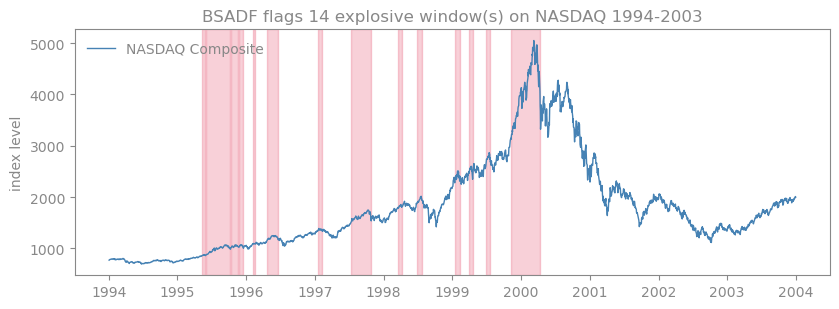

   flagged: 1995-05-10  ->  1995-05-30
   flagged: 1995-06-02  ->  1995-10-10
   flagged: 1995-10-11  ->  1995-11-21
   flagged: 1995-11-27  ->  1995-12-14
   flagged: 1996-02-05  ->  1996-02-20
   flagged: 1996-04-23  ->  1996-06-20
   flagged: 1997-01-16  ->  1997-02-05
   flagged: 1997-07-10  ->  1997-10-27
   flagged: 1998-03-19  ->  1998-04-07
   flagged: 1998-06-29  ->  1998-07-24
   flagged: 1999-01-15  ->  1999-02-09
   flagged: 1999-03-29  ->  1999-04-19
   flagged: 1999-06-30  ->  1999-07-22
   flagged: 1999-11-11  ->  2000-04-12


In [7]:
from fredapi import Fred

try:
    fred = Fred()  # reads FRED_API_KEY from the environment
    nasdaq = fred.get_series("NASDAQCOM").dropna()
    nasdaq = nasdaq["1994":"2003"]
    lp_real = np.log(nasdaq)
    nmin_r = psy_minimum_window(len(lp_real))
    bsadf_r = get_bsadf_sequence(lp_real, nmin_r)
    cv_r = simulate_psy_critical_values(len(lp_real), nmin_r, n_simulations=300, level=0.95)
    bsadf_cv_r = pd.Series(cv_r["bsadf_sequence_cv"], index=bsadf_r.index)
    episodes_r = get_bubble_episodes(bsadf_r, bsadf_cv_r, min_duration=10)

    fig, ax1 = plt.subplots(figsize=(8.5, 3.2))
    ax1.plot(nasdaq.index, nasdaq.values, lw=1, c="steelblue", label="NASDAQ Composite")
    for a, b in episodes_r:
        ax1.axvspan(a, b, color="crimson", alpha=0.2)
    ax1.set_ylabel("index level"); ax1.legend(loc="upper left")
    ax1.set_title(f"BSADF flags {len(episodes_r)} explosive window(s) on NASDAQ 1994-2003")
    plt.tight_layout(); plt.show()
    for a, b in episodes_r:
        print(f"   flagged: {a.date()}  ->  {b.date()}")
except Exception as e:
    print(f"FRED fetch unavailable ({type(e).__name__}: {e}); skipping the real-data illustration.")

## 5. Volatility-robust SADF: holding size under non-stationary volatility

<!-- WAVE29-BREAKS -->
The plain SADF / GSADF sup-ADF statistic has a null distribution that assumes
**homoskedastic** errors. Under **non-stationary volatility** the test over-rejects
and flags **spurious** bubbles. `volatility_robust_sadf` (Harvey, Leybourne, Sollis
and Taylor, 2016) recomputes the *same* sup-ADF statistics but calibrates the
critical values by a **wild bootstrap** (Rademacher sign-flip of the first-difference
residuals), which preserves the series' own volatility pattern while destroying any
explosive autocorrelation, restoring correct size.

**Regime tag (verbatim, Appraisal 26):** *prefer it over plain SADF/GSADF when the
series' volatility may be non-stationary: it holds nominal size where plain SADF
over-rejects ~9x, at a modest power cost, and converges to plain SADF under constant
volatility. Pairs with the admitted GSADF/BSADF.* Evidence:
`library_extension/appraisals/26_verdict.md`.

In [8]:
# WAVE29-BREAKS: empirical SIZE of plain GSADF vs vol-robust under a variance break
from RiskLabAI.features.structural_breaks import volatility_robust_sadf, pelt_change_points

def variance_break_random_walk(n, seed):
    rng = np.random.default_rng(seed)
    shocks = rng.standard_normal(n)
    shocks[n // 2:] *= 4.0                 # 4x variance break, NO explosive (bubble) root
    return np.cumsum(shocks)

n_mc, reps = 200, 40
nmin_mc = psy_minimum_window(n_mc)
homosk_cv = simulate_psy_critical_values(n_mc, nmin_mc, n_simulations=400, level=0.95)["gsadf_global_cv"]

plain_rejections = vr_rejections = 0
for r in range(reps):
    y = variance_break_random_walk(n_mc, 1000 + r)
    if get_gsadf_statistic(pd.Series(y), nmin_mc) > homosk_cv:   # homoskedastic critical value
        plain_rejections += 1
    if volatility_robust_sadf(y, n_bootstrap=99, random_state=r)["reject_gsadf"]:
        vr_rejections += 1

plain_size, vr_size = plain_rejections / reps, vr_rejections / reps
print(f"4x variance break, NO true bubble ({reps} realizations; nominal size = 0.05):")
print(f"  plain GSADF empirical size       = {plain_size:.3f}   (over-rejects -> spurious bubbles)")
print(f"  volatility-robust empirical size = {vr_size:.3f}   (holds nominal size)")
print("  => the homoskedastic critical value is far too small under non-stationary volatility.")

4x variance break, NO true bubble (40 realizations; nominal size = 0.05):
  plain GSADF empirical size       = 0.525   (over-rejects -> spurious bubbles)
  volatility-robust empirical size = 0.050   (holds nominal size)
  => the homoskedastic critical value is far too small under non-stationary volatility.


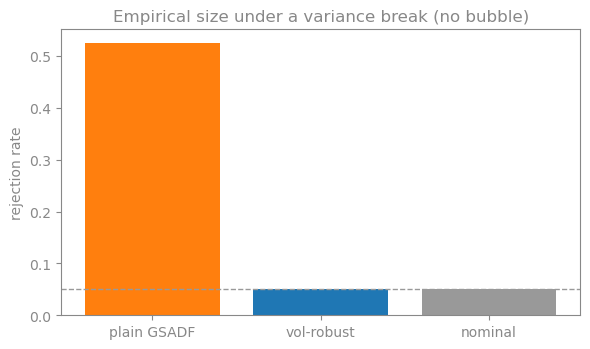

In [9]:
# WAVE29-BREAKS: empirical size, plain vs vol-robust vs nominal
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar(["plain GSADF", "vol-robust", "nominal"], [plain_size, vr_size, 0.05],
       color=["#ff7f0e", "#1f77b4", "#999999"])
ax.axhline(0.05, color="#999999", ls="--", lw=1)
ax.set_title("Empirical size under a variance break (no bubble)")
ax.set_ylabel("rejection rate")
fig.tight_layout()
plt.show()

In [10]:
# WAVE29-BREAKS: under a genuine constant-volatility bubble the vol-robust test still detects
rng = np.random.default_rng(3)
n = 300
y_bub = np.zeros(n)
for t in range(1, n):
    y_bub[t] = (1.06 * y_bub[t - 1] if 100 <= t < 160 else y_bub[t - 1]) + rng.standard_normal()

vr_bub = volatility_robust_sadf(y_bub, n_bootstrap=199, random_state=1)
print("Constant-volatility series with a genuine explosive episode (t=100..160):")
print(f"  vol-robust GSADF = {vr_bub['gsadf']:.2f}   p-value = {vr_bub['gsadf_pvalue']:.3f}"
      f"   ->  rejects? {vr_bub['reject_gsadf']}")
print("  => modest power cost, NOT a loss of power: a real constant-vol bubble is still flagged.")

Constant-volatility series with a genuine explosive episode (t=100..160):
  vol-robust GSADF = 19.39   p-value = 0.005   ->  rejects? True
  => modest power cost, NOT a loss of power: a real constant-vol bubble is still flagged.


## 6. PELT: multiple and variance change-points CUSUM misses

<!-- WAVE29-BREAKS -->
de Prado's CUSUM (Chu-Stinchcombe-White) test targets a **single mean shift** and is
blind to a pure **variance** change. **PELT** (Killick, Fearnhead and Eckley, 2012)
finds the exact set of **multiple** change-points minimizing a segment cost plus a
per-change penalty; with a Gaussian (mean-and-variance) cost it dates multiple and
variance breaks without over-segmenting.

**Regime tag (verbatim, Appraisal 26):** *prefer it over CUSUM for detecting and
dating multiple and/or variance change-points (which CUSUM misses), without
over-segmenting; CUSUM remains adequate for a single mean shift.* `pelt_change_points`
is provided through the BSD-2 `ruptures` package. Evidence:
`library_extension/appraisals/26_verdict.md`.

In [11]:
# WAVE29-BREAKS: PELT on (a) three mean+variance change-points and (b) a pure variance shift
rng = np.random.default_rng(2)
multi = np.concatenate([
    rng.standard_normal(80),
    rng.standard_normal(80) + 4.0,            # mean shift
    2.5 * rng.standard_normal(80) + 4.0,      # variance shift (mean unchanged)
    rng.standard_normal(80),                  # mean + variance shift back
])
cps_multi = pelt_change_points(multi, penalty_multiplier=2.0, min_size=15, jump=5)
print("Three true change-points at [80, 160, 240]; PELT detects:", cps_multi)

rng = np.random.default_rng(11)
var_only = np.concatenate([rng.standard_normal(100), 3.0 * rng.standard_normal(100)])
cps_var = pelt_change_points(var_only)        # CUSUM is blind to this pure variance break
print("One true PURE-VARIANCE change-point at [100]; PELT detects:", cps_var)

Three true change-points at [80, 160, 240]; PELT detects: [80, 160, 240]
One true PURE-VARIANCE change-point at [100]; PELT detects: [105]


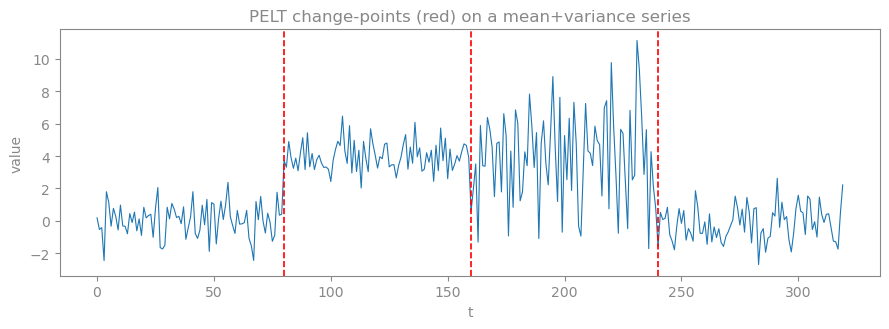

In [12]:
# WAVE29-BREAKS: visualize the PELT segmentation of the multi-break series
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(multi, lw=0.8, color="#1f77b4")
for c in cps_multi:
    ax.axvline(c, color="red", ls="--", lw=1.2)
ax.set_title("PELT change-points (red) on a mean+variance series")
ax.set_xlabel("t"); ax.set_ylabel("value")
fig.tight_layout()
plt.show()